In [1]:

!pip install xgboost shap -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap, warnings
warnings.filterwarnings("ignore")

from google.colab import files
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

 UPLOAD + LOAD DATASET

In [2]:

uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])
df.columns = df.columns.str.strip()

print("Shape:", df.shape)
display(df.head())
display(df.info())

Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

None

CREATE REQUIRED FEATURES IF MISSING

In [3]:

bill_cols = ["BILL_AMT1","BILL_AMT2","BILL_AMT3","BILL_AMT4","BILL_AMT5","BILL_AMT6"]
pay_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]

if "BILL_AMT_SUM" not in df.columns:
    df["BILL_AMT_SUM"] = df[bill_cols].sum(axis=1)

if "LIMIT_BAL_LOG" not in df.columns:
    df["LIMIT_BAL_LOG"] = np.log1p(df["LIMIT_BAL"])

if "risk_leak" not in df.columns:
    df["risk_leak"] = df[pay_cols].mean(axis=1)

if "RISK_RATING" not in df.columns:
    df["RISK_RATING"] = pd.cut(
        df["risk_leak"],
        bins=[-3, -1, 0.5, 2, 10],
        labels=["Low", "Medium", "High", "Very High"]
    )

if "CITY" not in df.columns:
    np.random.seed(42)
    df["CITY"] = np.random.choice(["Taipei", "Kaohsiung", "Taichung", "Tainan"], len(df))

print("Final shape:", df.shape)
display(df.head())

Final shape: (30000, 30)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month,BILL_AMT_SUM,LIMIT_BAL_LOG,risk_leak,RISK_RATING,CITY
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,1,7704.0,9.903538,-0.333333,Medium,Taichung
1,2,120000.0,2,2,2,26,-1,2,0,0,...,1000.0,1000.0,0.0,2000.0,1,17077.0,11.695255,0.500000,Medium,Tainan
2,3,90000.0,2,2,2,34,0,0,0,0,...,1000.0,1000.0,1000.0,5000.0,0,101653.0,11.407576,0.000000,Medium,Taipei
3,4,50000.0,2,2,1,37,0,0,0,0,...,1200.0,1100.0,1069.0,1000.0,0,231334.0,10.819798,0.000000,Medium,Taichung
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,10000.0,9000.0,689.0,679.0,0,109339.0,10.819798,-0.333333,Medium,Taichung


EDA: TARGET, MISSING VALUES, STATS

Missing values:


,0


Target distribution:


,count
default.payment.next.month,
0,23364
1,6636


,proportion
default.payment.next.month,
0,77.88
1,22.12


,mean,median,std
LIMIT_BAL,167484.322667,140000.000000,129747.661567
AGE,35.485500,34.000000,9.217904
BILL_AMT_SUM,269861.671200,126311.000000,379564.331162
LIMIT_BAL_LOG,11.663016,11.849405,0.941120
risk_leak,-0.182439,0.000000,0.982176


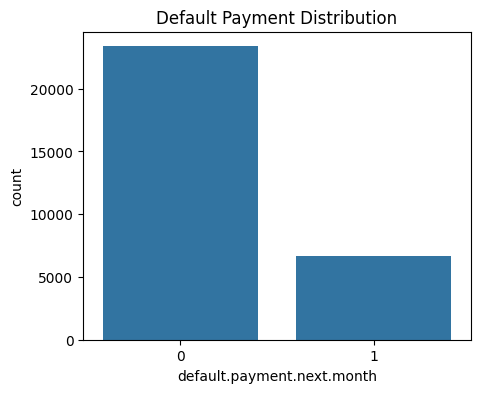

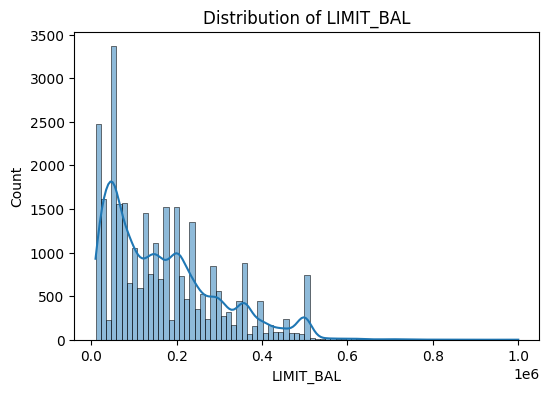

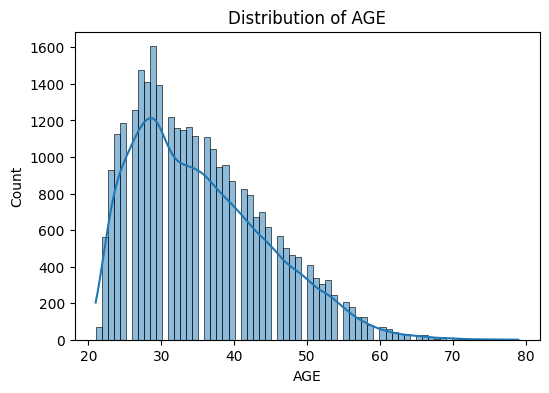

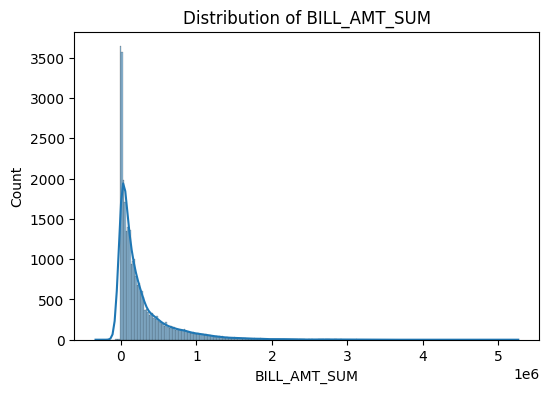

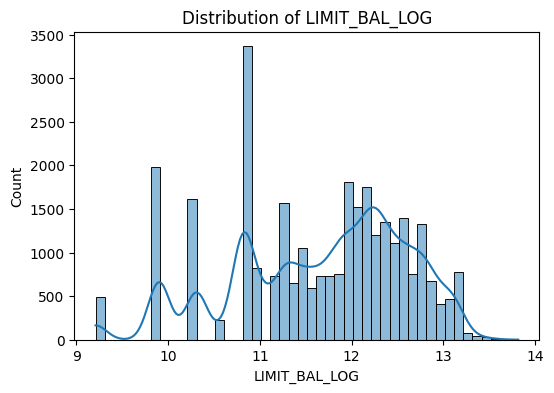

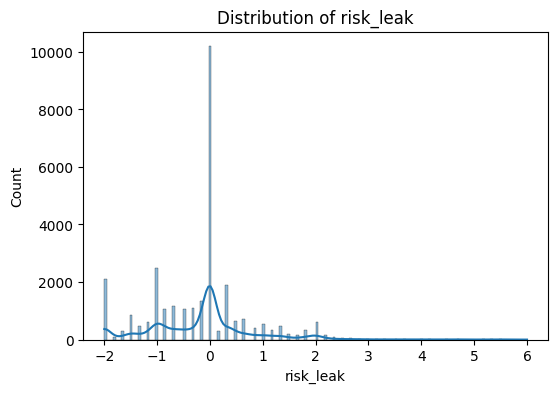

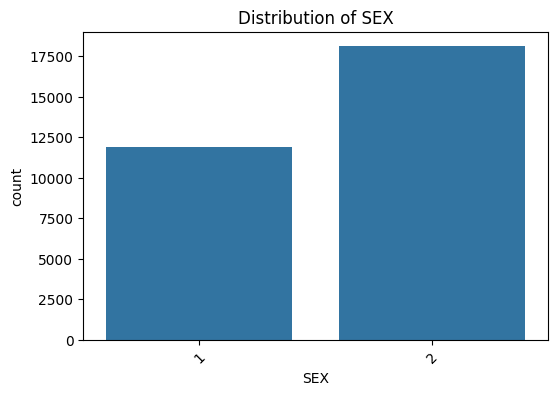

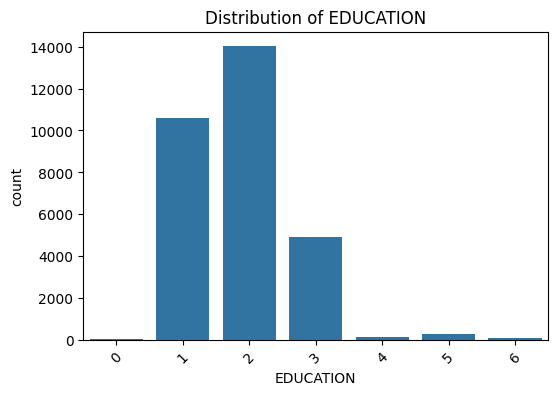

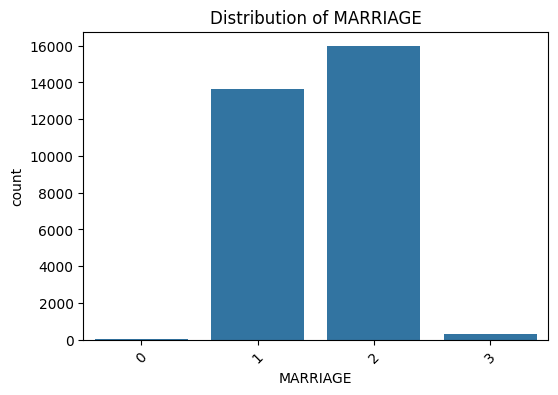

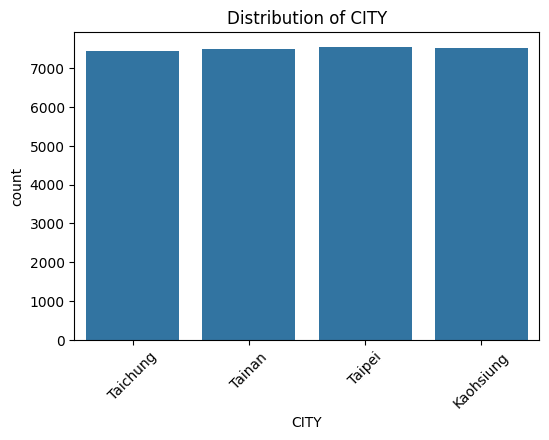

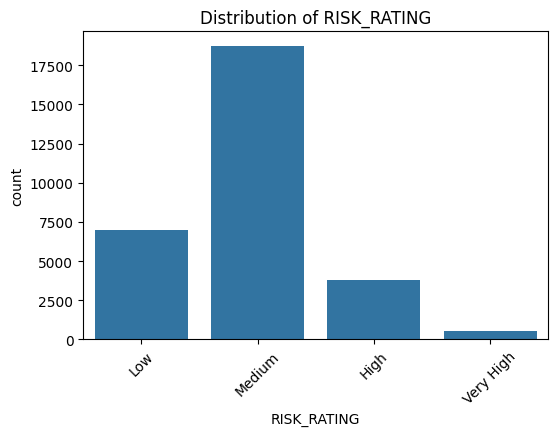

In [4]:

target = "default.payment.next.month"

print("Missing values:")
display(df.isnull().sum()[df.isnull().sum() > 0])

print("Target distribution:")
display(df[target].value_counts())
display(df[target].value_counts(normalize=True) * 100)

key_cols = ["LIMIT_BAL", "AGE", "BILL_AMT_SUM", "LIMIT_BAL_LOG", "risk_leak"]
display(df[key_cols].agg(["mean", "median", "std"]).T)

plt.figure(figsize=(5,4))
sns.countplot(x=target, data=df)
plt.title("Default Payment Distribution")
plt.show()

for col in key_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

for col in ["SEX", "EDUCATION", "MARRIAGE", "CITY", "RISK_RATING"]:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

CORRELATION + DEFAULT RISK FEATURES

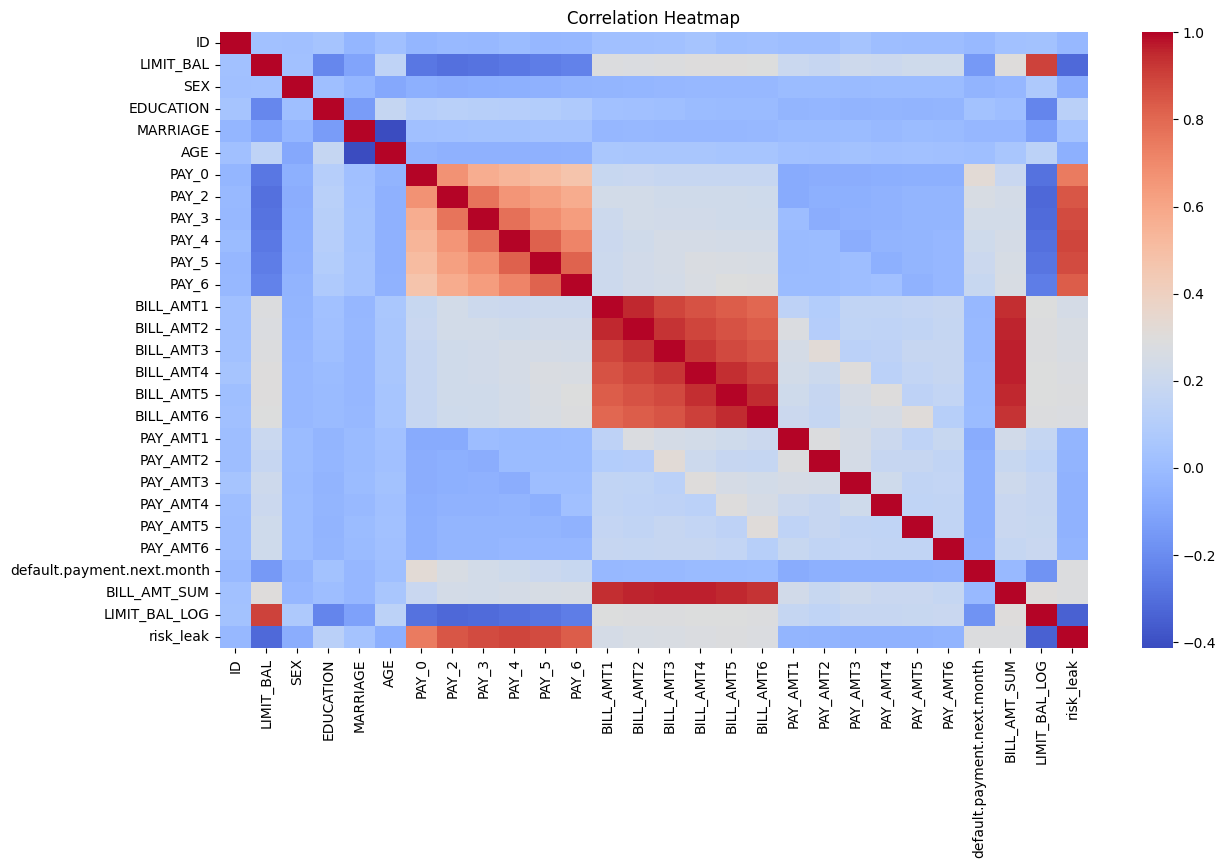

Correlation with target:


,default.payment.next.month
default.payment.next.month,1.000000
PAY_0,0.324794
risk_leak,0.281955
PAY_2,0.263551
PAY_3,0.235253
PAY_4,0.216614
PAY_5,0.204149
PAY_6,0.186866
EDUCATION,0.028006
AGE,0.013890


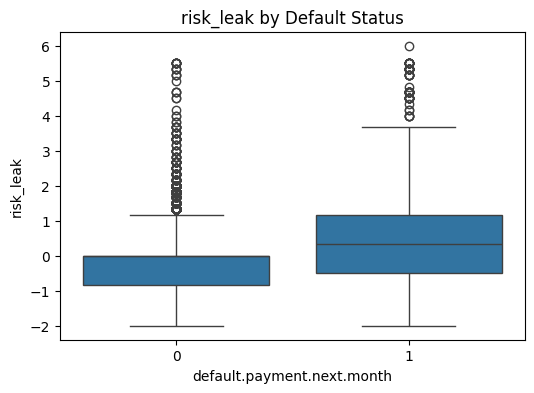

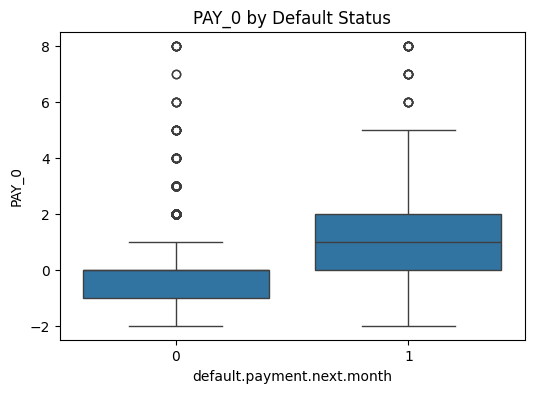

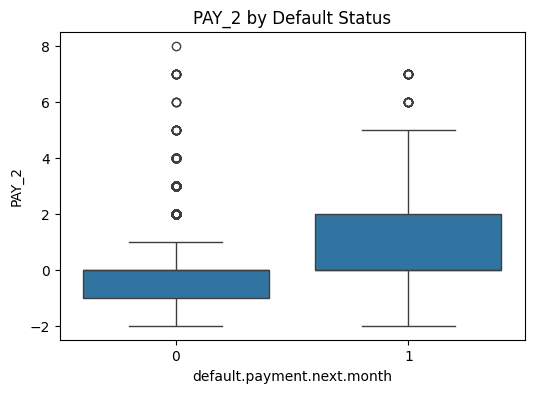

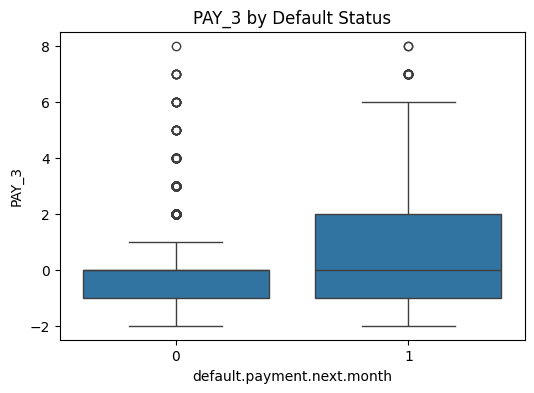

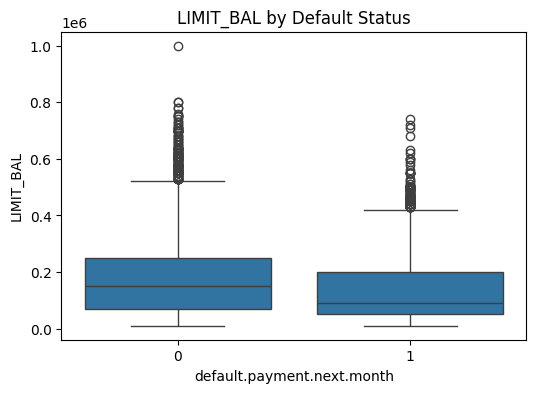

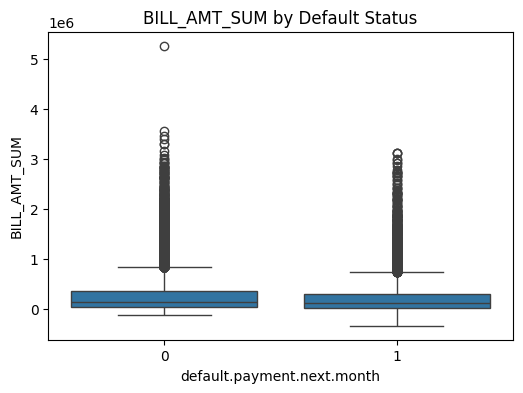

In [5]:

num_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(14,8))
sns.heatmap(num_df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

print("Correlation with target:")
display(num_df.corr()[target].sort_values(ascending=False).head(12))

for col in ["risk_leak", "PAY_0", "PAY_2", "PAY_3", "LIMIT_BAL", "BILL_AMT_SUM"]:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=target, y=col, data=df)
    plt.title(f"{col} by Default Status")
    plt.show()

 PREPROCESSING

In [6]:

data = df.copy()

if "ID" in data.columns:
    data.drop(columns=["ID"], inplace=True)

X = data.drop(columns=[target])
y = data[target]

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns

X[num_cols] = SimpleImputer(strategy="median").fit_transform(X[num_cols])
X[cat_cols] = SimpleImputer(strategy="most_frequent").fit_transform(X[cat_cols])

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train target balance:")
display(y_train.value_counts(normalize=True) * 100)

Train: (24000, 32) Test: (6000, 32)
Train target balance:


,proportion
default.payment.next.month,
0,77.879167
1,22.120833


TRAIN 7 MODELS

In [7]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "SVM": SVC(probability=True, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "AUC_ROC": roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results).sort_values("AUC_ROC", ascending=False)
display(results_df)

,Model,Accuracy,Precision,Recall,F1,AUC_ROC
5,Gradient Boosting,0.818167,0.659030,0.368500,0.472692,0.779611
6,XGBoost,0.811167,0.622785,0.370761,0.464809,0.763191
3,Random Forest,0.815667,0.654545,0.352675,0.458374,0.759721
1,SVM,0.777333,0.496986,0.559156,0.526241,0.755092
0,Logistic Regression,0.759833,0.464815,0.567445,0.511028,0.722247
4,KNN,0.791833,0.547101,0.341372,0.420418,0.695469
2,Decision Tree,0.726333,0.383247,0.389601,0.386398,0.605711


ROC CURVES FOR ALL MODELS

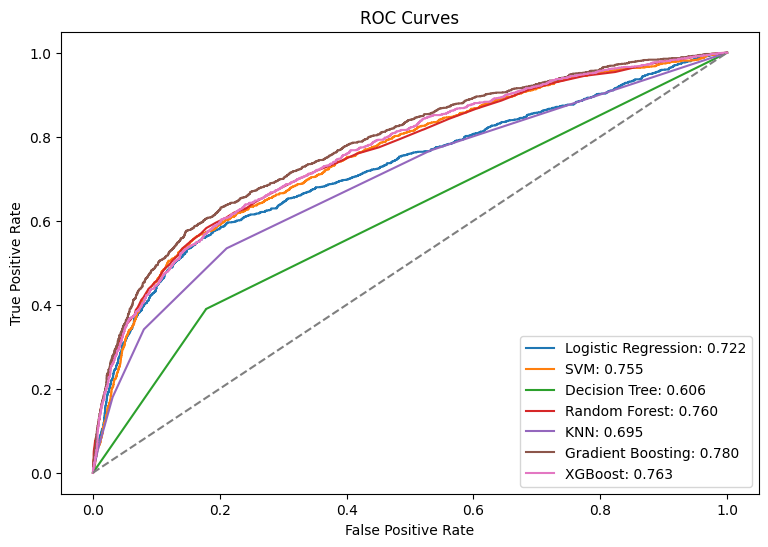

In [8]:

plt.figure(figsize=(9,6))

for name, model in models.items():
    proba = model.predict_proba(X_test_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name}: {auc:.3f}")

plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

MODEL PERFORMANCE COMPARISON BAR CHART

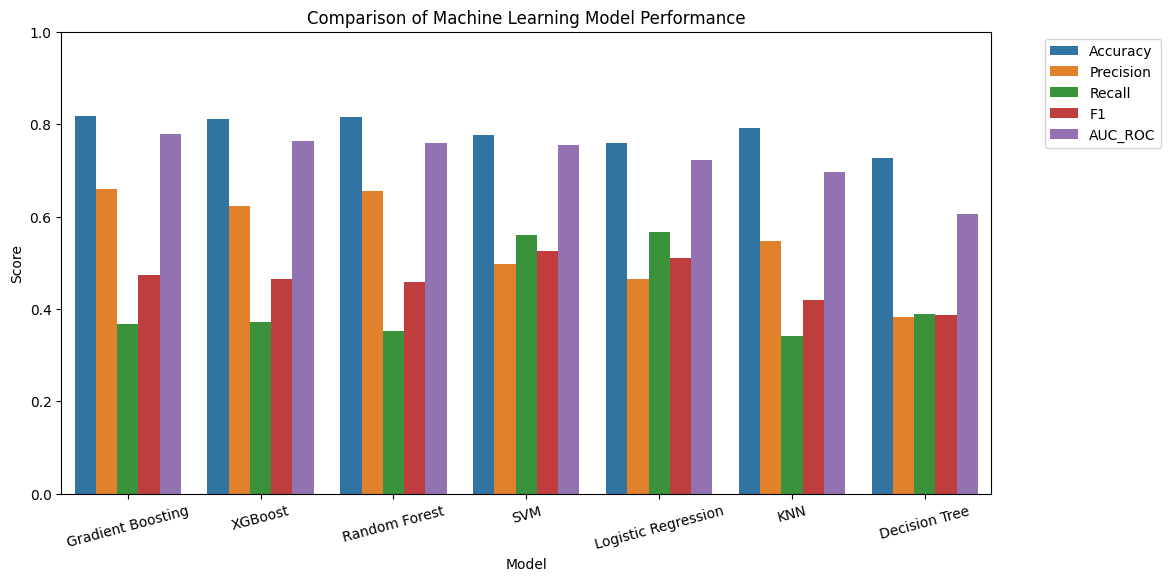

In [15]:

metrics = ["Accuracy", "Precision", "Recall", "F1", "AUC_ROC"]

results_melted = results_df.melt(
    id_vars="Model",
    value_vars=metrics,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_melted,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.xticks(rotation=15)
plt.ylim(0,1)
plt.title("Comparison of Machine Learning Model Performance")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

 HYPERPARAMETER TUNING FOR RANDOM FOREST

In [9]:

rf = RandomForestClassifier(class_weight="balanced", random_state=42)

param_dist = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train_s, y_train)

best_model = search.best_estimator_
print("Best parameters:", search.best_params_)

pred = best_model.predict(X_test_s)
proba = best_model.predict_proba(X_test_s)[:, 1]

tuned_result = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "Accuracy": accuracy_score(y_test, pred),
    "Precision": precision_score(y_test, pred),
    "Recall": recall_score(y_test, pred),
    "F1": f1_score(y_test, pred),
    "AUC_ROC": roc_auc_score(y_test, proba)
}])

display(tuned_result)

Best parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10}


,Model,Accuracy,Precision,Recall,F1,AUC_ROC
0,Tuned Random Forest,0.783667,0.509764,0.57046,0.538407,0.774683


CONFUSION MATRIX + FEATURE IMPORTANCE

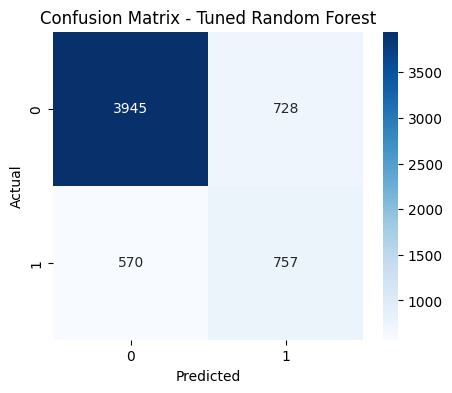

,Feature,Importance
5,PAY_0,0.167201
25,risk_leak,0.155874
6,PAY_2,0.080601
7,PAY_3,0.043794
23,BILL_AMT_SUM,0.038464
8,PAY_4,0.034097
17,PAY_AMT1,0.033164
18,PAY_AMT2,0.033106
11,BILL_AMT1,0.032182
24,LIMIT_BAL_LOG,0.032018


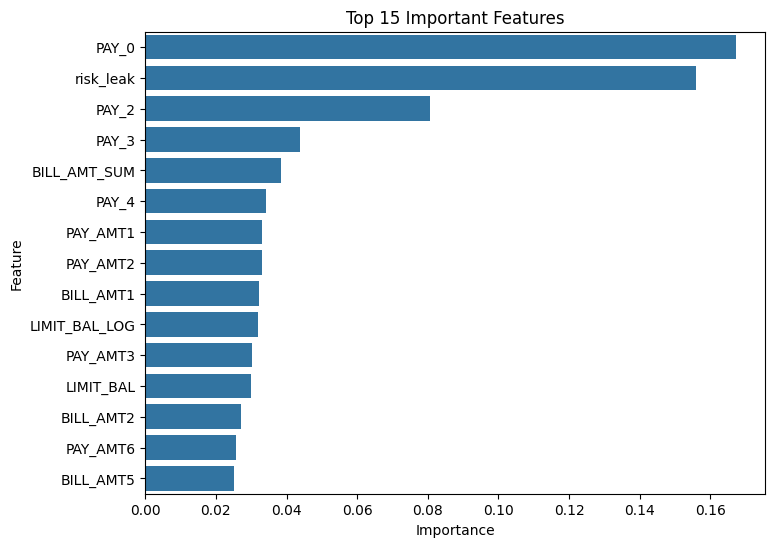

In [10]:

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance.head(15))

plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=importance.head(15))
plt.title("Top 15 Important Features")
plt.show()

CLASS IMBALANCE PIE CHART

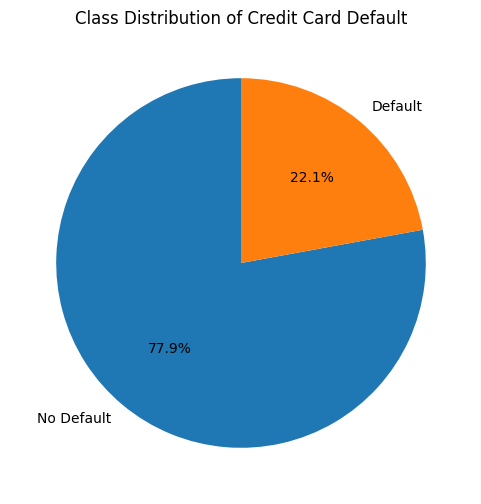

In [13]:


target_counts = df[target].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    target_counts,
    labels=["No Default", "Default"],
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Class Distribution of Credit Card Default")
plt.show()

FEATURE IMPORTANCE HEATMAP

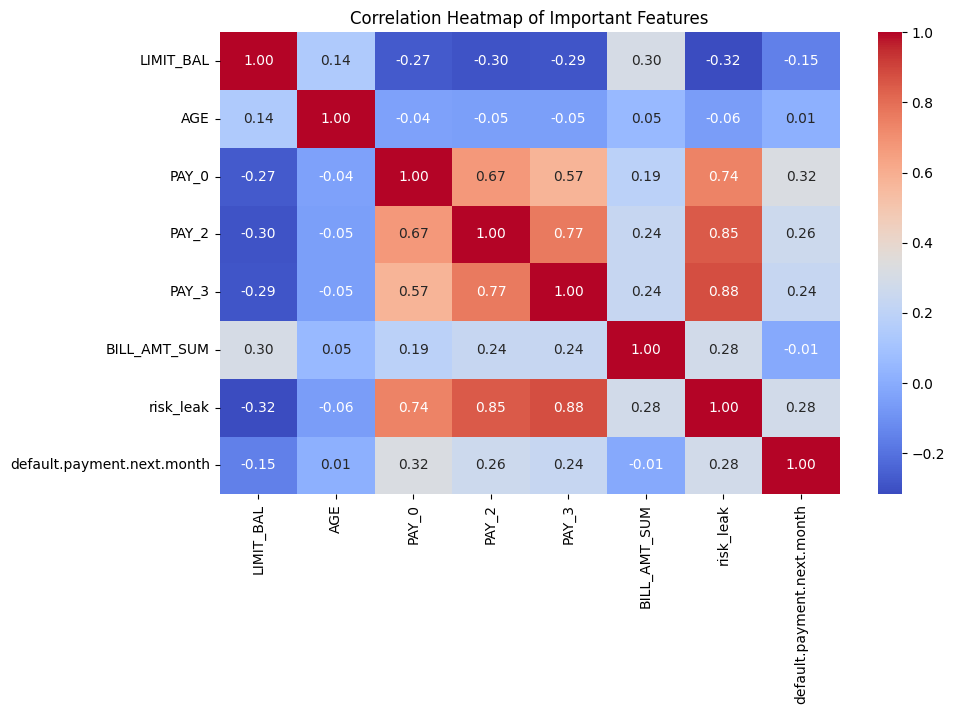

In [14]:


top_features = [
    "LIMIT_BAL",
    "AGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "BILL_AMT_SUM",
    "risk_leak",
    target
]

plt.figure(figsize=(10,6))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Important Features")
plt.show()

SHAP EXPLAINABILITY

X_test_sample shape: (300, 32)
SHAP values shape: (300, 32)


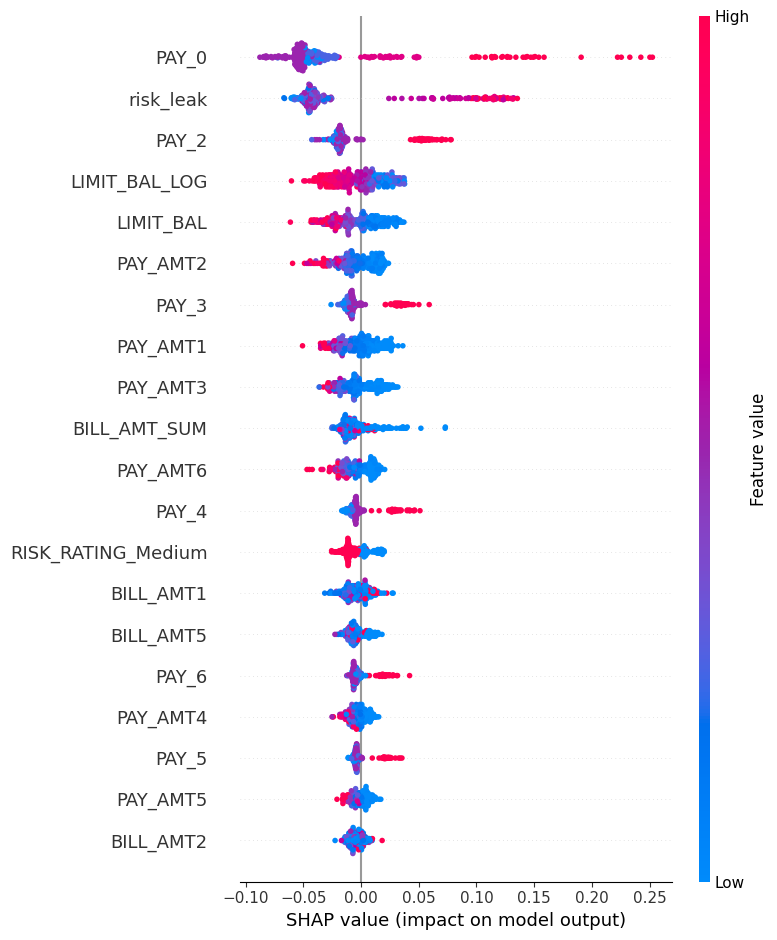

In [12]:


X_test_sample = pd.DataFrame(X_test_s, columns=X.columns).sample(300, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_sample)

print("X_test_sample shape:", X_test_sample.shape)


if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    if len(shap_values.shape) == 3:
        shap_values_to_plot = shap_values[:, :, 1]
    else:
        shap_values_to_plot = shap_values

print("SHAP values shape:", shap_values_to_plot.shape)

shap.summary_plot(
    shap_values_to_plot,
    X_test_sample,
    feature_names=X_test_sample.columns
)